# 1. Motivation

The dataset used consists of the combination of three main sub-datasets.
- A dataset from the Icelandic Statistical Bureau (*Hagstofan*) consisting of monthly catch sizes and value from 1982 for different fish species, as well as the place of landing. [[1]](#ref1) This dataset was enriched with the coordinates of the landing ports, allowing for spatial visualization of the data. 
- A dataset from the Icelandic Statistical Bureau (*Hagstofan*) cosisting of various operating accounts of the fishing industry, including aggregated costs, revenue and profit. [[2]](#ref2)
- A dataset from the Icelandic Directorate of Fisheries (*Fiskistofa*) containing data on historical catch quotas of fisheries operating in Iceland.[[3]](#ref3)

Together, these sources provide a comprehensive view of the Icelandic fishing industry over recent decades. By combining operational, spatial, and economic factors we can construct a overview of the industry's evolution from multiple perspectives.

The goal is to present this overview in an approachable and understandable manner to the user through excellent visualizations. We aim to do this by first guiding the user through the main events that shaped the industry and provide context, before allowing free exploration of the data through interactive visualizations.

In [20]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 2. Basic stats

### General cleaning and preprocessing
The following involves data cleaning and preprocessing of the catch data. Some of the steps applied in the following code block include:
- Translation of data to english for easier interpretation.
- Restructuring dataframe using pivot_table transformation to make working with the dataframe easier.
- Dropping of entries related to landings in foreign ports as the foucs is on Iceland.
- NaN handling of illegitimate data.

In [21]:
# Read in afli_data1.csv, afli_data2.csv, and afli_data3.csv, and combine them into a single DataFrame
df1 = pd.read_csv('afli_data1.csv')
df2 = pd.read_csv('afli_data2.csv')
df3 = pd.read_csv('afli_data3.csv')
combined_df = pd.concat([df1, df2, df3], ignore_index=True)

# Delete the "Unnamed: 0" column from the combined DataFrame
combined_df.drop(columns=['Unnamed: 0'], inplace=True)
# Change name of "Afli og aflaverðmæti eftir fisktegund, löndunarhöfn, landsvæðum og mánuðum 1982-2024" column to "Afli"
combined_df.rename(columns={'Afli og aflaverðmæti eftir fisktegund, löndunarhöfn, landsvæðum og mánuðum 1982-2024': 'Afli'}, inplace=True)
# Delete rows where "Löndunarhöfn" is "A.-Þýskaland", "Bandaríkin", "Belgía", "Bretland", "Danmörk", "Domeniska Lýðveldið", "Frakkland", "Færeyjar", "Grænland", "Holland", "Írland", "Japan", "Kanada", "Litháen", "Namibía", "Noregur", "Skotland", "Spánn", "Svíþjóð", "Tyrkland", "Þýskaland" and "Önnur löndun"
combined_df = combined_df[~combined_df['Löndunarhöfn'].isin(['A.-Þýskaland', 'Bandaríkin', 'Belgía', 'Bretland', 'Danmörk', 'Domeniska Lýðveldið', 'Frakkland', 'Færeyjar', 'Grænland', 'Holland', 'Írland', 'Japan', 'Kanada', 'Litháen', 'Namibía', 'Noregur', 'Skotland', 'Spánn', 'Svíþjóð', 'Tyrkland', 'Þýskaland', 'Önnur löndun', 'Domeniska lýðveldið'])]

# Convert months to numeric values
combined_df['Mánuður'] = combined_df['Mánuður'].map({
    'janúar': 1,
    'febrúar': 2,
    'mars': 3,
    'apríl': 4,
    'maí': 5,
    'júní': 6,
    'júlí': 7,
    'ágúst': 8,
    'september': 9,
    'október': 10,
    'nóvember': 11,
    'desember': 12
})

# Convert to numeric — '..' and other non-numeric become NaN automatically
combined_df['Afli'] = pd.to_numeric(combined_df['Afli'], errors='coerce')

# Pivot the dataframe so that values in "Eining" become separate columns ("Magn" and "Verðmæti")
combined_df = (
    combined_df
    .pivot_table(
        index=["Fisktegund", "Löndunarhöfn", "Ár", "Mánuður"],
        columns="Eining",
        values="Afli",
        aggfunc="first"   
    )
    .reset_index()
)
# Remove the column index name
combined_df.columns.name = None

# Translate column names to English
combined_df.rename(columns={
    'Fisktegund': 'Species',
    'Löndunarhöfn': 'Port',
    'Ár': 'Year',
    'Mánuður': 'Month',
    'Magn': 'Quantity',
    'Verðmæti': 'Value'
}, inplace=True)

# Drop negative values of Quantity and Value
combined_df = combined_df[(combined_df["Quantity"] >= 0) & (combined_df["Value"] >= 0)]

After beginning working on the project, we noticed that monthly data was missing from the dataset for the years 1984 and 1999, therefore monthly plots for these years were excluded from visualizations. Also, geographical data was missing in for 1990 and that year was therefore excluded in all maps.

### Basic stats
##### Catch Data
Lets take a look at the catch data

In [22]:
combined_df.iloc[150:153]

,Species,Port,Year,Month,Quantity,Value
150,Annar botnfiskur,Akranes,1983,11,6.0,3.0
151,Annar botnfiskur,Akranes,1983,12,2.0,1.0
152,Annar botnfiskur,Akranes,1984,1,13.0,6.0


The Species column refers to the fish species catched, and Port the landing port of the catch. Quantity correponds to the catch weight in tons, while Value is the monetary value of the catch in thousands of ISK. Some basic stats for these columns follow:

In [23]:
print("Catch dataframe contains the columns: " + ", ".join(combined_df.columns))
print(f"Dataframe has {combined_df.shape[0]} rows")
print(f"The data ranges from {combined_df['Year'].min()} to {combined_df['Year'].max()}")
print(f"Number of unique species: {combined_df['Species'].nunique()}")
print(f"Number of unique ports: {combined_df['Port'].nunique()}")
print(f"\nQuantity  min: {combined_df['Quantity'].min():,.0f}, max: {combined_df['Quantity'].max():,.0f},   mean: {combined_df['Quantity'].mean():,.2f}")
print(f"Value     min: {combined_df['Value'].min():,.0f}, max: {combined_df['Value'].max():,.0f}, mean: {combined_df['Value'].mean():,.2f}")

Catch dataframe contains the columns: Species, Port, Year, Month, Quantity, Value
Dataframe has 306914 rows
The data ranges from 1982 to 2024
Number of unique species: 41
Number of unique ports: 80

Quantity  min: 0, max: 124,060,   mean: 190.29
Value     min: 0, max: 2,795,908, mean: 11,487.51


The data does include alot of catch entries as the date range is large. The number of fish species included, a well as the number of landing ports, are also substantial. The min, max and mean stats for Quantity and Value indicate these values have a wide range.

The following shows the distributions of the Value and Quantity values.

<a id="fig1"></a>

**Figure 1: Distribution of Catches in Icelandic Fisheries**

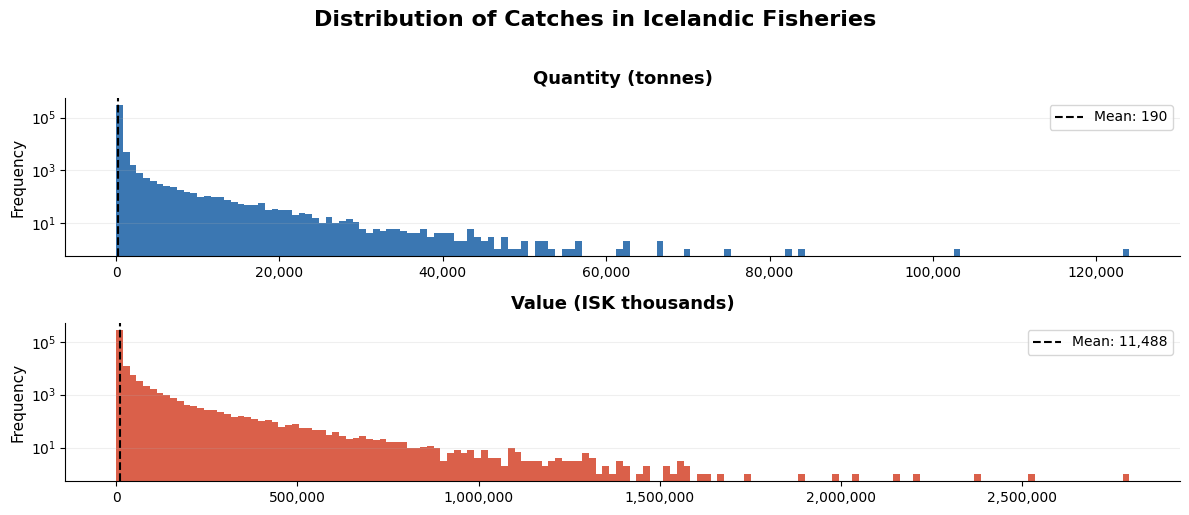

In [24]:
import matplotlib.ticker as ticker

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
fig.suptitle("Distribution of Catches in Icelandic Fisheries", fontsize=16, fontweight="bold", y=1.02)

qty_nonzero = combined_df["Quantity"]
val_nonzero = combined_df["Value"]

for ax, data, color, title in zip(
    [ax1, ax2],
    [qty_nonzero, val_nonzero],
    ["#185FA5", "#D4442A"],
    ["Quantity (tonnes)", "Value (ISK thousands)"]
):
    ax.hist(data, bins=150, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean: {data.mean():,.0f}")
    ax.legend(fontsize=10)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.set_yscale("log")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

These distributions show that the dataset includes many smaller landings, as the mean is heavily skewed to the left, while fewer, much larger entries are also present. The figure and the following calculations suggest a power law distribution is present as a small part of the entries account for a large share of the total Value and Quantity.

In [25]:
val_sorted = val_nonzero.sort_values(ascending=False).reset_index(drop=True)
total = val_sorted.sum()
cumulative = val_sorted.cumsum() / total * 100
for pct in [1, 5, 10, 20]:
    n = int(len(val_sorted) * pct / 100)
    print(f"Top {pct}% of entries account for {cumulative.iloc[n-1]:.1f}% of total value")

Top 1% of entries account for 36.5% of total value
Top 5% of entries account for 72.1% of total value
Top 10% of entries account for 86.2% of total value
Top 20% of entries account for 95.7% of total value


When analysing the species, we similarly see that certain fish species tend to dominate the Quantity and Value total aggregations. For example, the figure below shows that 5 species account for 75% of the total Quantity from 1982 to 2024.

<a id="fig2"></a>

**Figure 2: Species share of Icelandic Fisheries**

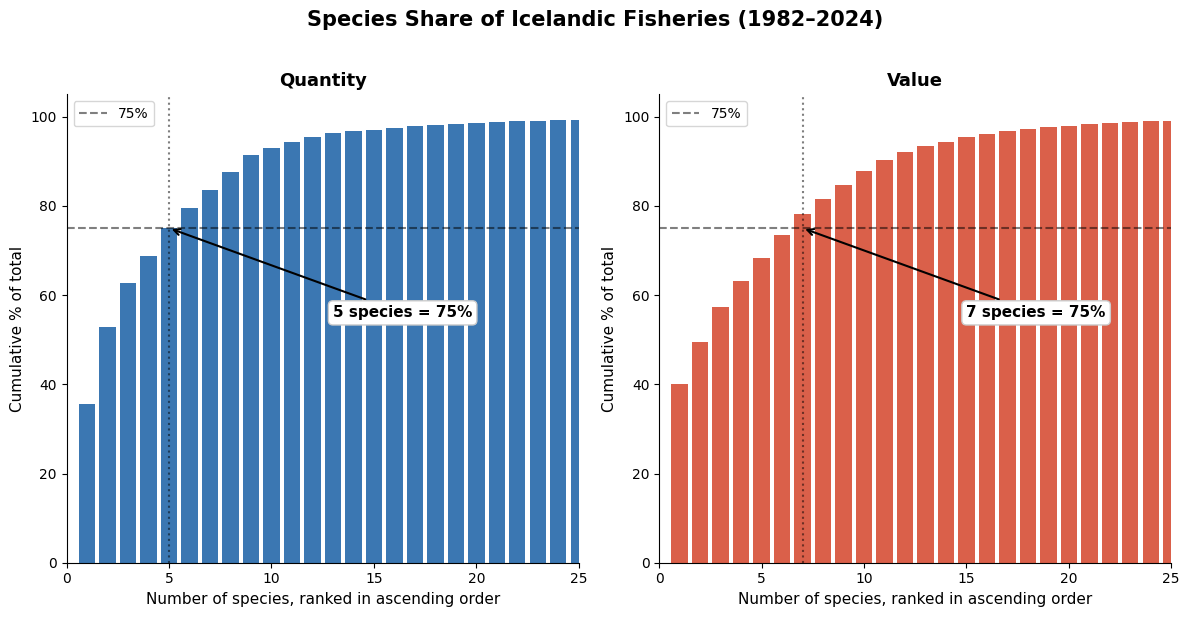

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Species Share of Icelandic Fisheries (1982–2024)", fontsize=15, fontweight="bold", y=1.02)

# All species sorted
all_qty = combined_df.groupby("Species")["Quantity"].sum().sort_values(ascending=False)
all_val = combined_df.groupby("Species")["Value"].sum().sort_values(ascending=False)

# Cumulative shares
cum_qty = (all_qty.cumsum() / all_qty.sum() * 100).values
cum_val = (all_val.cumsum() / all_val.sum() * 100).values

x = np.arange(1, len(all_qty) + 1)

# Quantity
ax1.bar(x, cum_qty, color="#185FA5", edgecolor="none", alpha=0.85)
ax1.axhline(75, color="black", linestyle="--", alpha=0.5, label="75%")
n75_qty = np.searchsorted(cum_qty, 75) + 1
ax1.axvline(n75_qty, color="black", linestyle=":", alpha=0.5)
ax1.annotate(f"{n75_qty} species = 75%", xy=(n75_qty, 75),
             xytext=(n75_qty + 8, 55), fontsize=11, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc"))
ax1.set_xlabel("Number of species, ranked in ascending order", fontsize=11)
ax1.set_ylabel("Cumulative % of total", fontsize=11)
ax1.set_title("Quantity", fontsize=13, fontweight="bold")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(fontsize=10)
ax1.set_xlim(0, 25)


# Value
ax2.bar(x, cum_val, color="#D4442A", edgecolor="none", alpha=0.85)
ax2.axhline(75, color="black", linestyle="--", alpha=0.5, label="75%")
n75_val = np.searchsorted(cum_val, 75) + 1
ax2.axvline(n75_val, color="black", linestyle=":", alpha=0.5)
ax2.annotate(f"{n75_val} species = 75%", xy=(n75_val, 75),
             xytext=(n75_val + 8, 55), fontsize=11, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc"))
ax2.set_xlabel("Number of species, ranked in ascending order", fontsize=11)
ax2.set_ylabel("Cumulative % of total", fontsize=11)
ax2.set_title("Value", fontsize=13, fontweight="bold")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(fontsize=10)
ax2.set_xlim(0, 25)



plt.tight_layout()
plt.show()

As a result we limit our data to the 5 main species to consider in this project, according to these two metrics.

In [27]:
species = ['Cod', 'Haddock', 'Herring', 'Capelin', 'Mackerel']

In [28]:
# Translate names and map dataframe
combined_df['Species'] = combined_df['Species'].map({
    'Þorskur': 'Cod',
    'Ýsa': 'Haddock',
    'Síld': 'Herring',
    'Loðna': 'Capelin',
    'Makríll': 'Mackerel'
})
combined_df = combined_df.dropna(subset=["Species"])


The following figure shows how the yearly species catch sizes have deviated from the over the year. Minimal smoothing has been applied. Relatively high variations are present between years.

<a id="fig3"></a>

**Figure 3: Catch by Species Over Time**

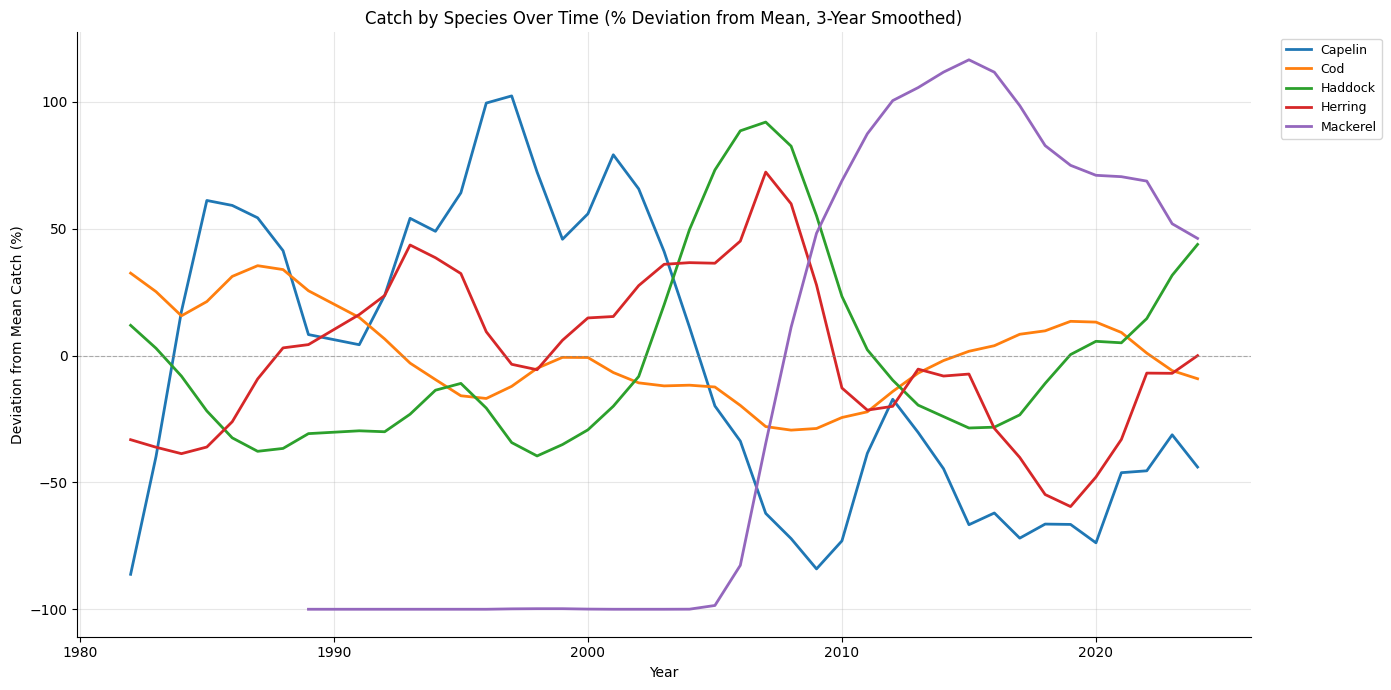

In [29]:
colors = {
    'Cod': '#2E6B8A',
    'Haddock': '#4EADC5',
    'Herring': '#F2A541',
    'Capelin': '#E8645A',
    'Mackerel': '#7CB98A'
}

species_yearly = (
    combined_df
    .groupby(["Year", "Species"], as_index=False)["Quantity"]
    .sum()
)

pivot_species = species_yearly.pivot(
    index="Year",
    columns="Species",
    values="Quantity"
)

# Normalize: express each species as % deviation from its own mean
species_means = pivot_species.mean()
pivot_normalized = (pivot_species - species_means) / species_means * 100

# Smoothing: 3-year rolling average
pivot_smoothed = pivot_normalized.rolling(window=3, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 7))

for col in pivot_smoothed.columns:
    ax.plot(
        pivot_smoothed.index,
        pivot_smoothed[col],
        linewidth=2,
        label=col
    )

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)

ax.set_title("Catch by Species Over Time (% Deviation from Mean, 3-Year Smoothed)")
ax.set_xlabel("Year")
ax.set_ylabel("Deviation from Mean Catch (%)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

We now explore catch compositions over the timeperiod, with respect to the two metrics, Quantity and Value.

<a id="fig4"></a>

**Figure 4: Icelandic Fisheries — Species Composition**

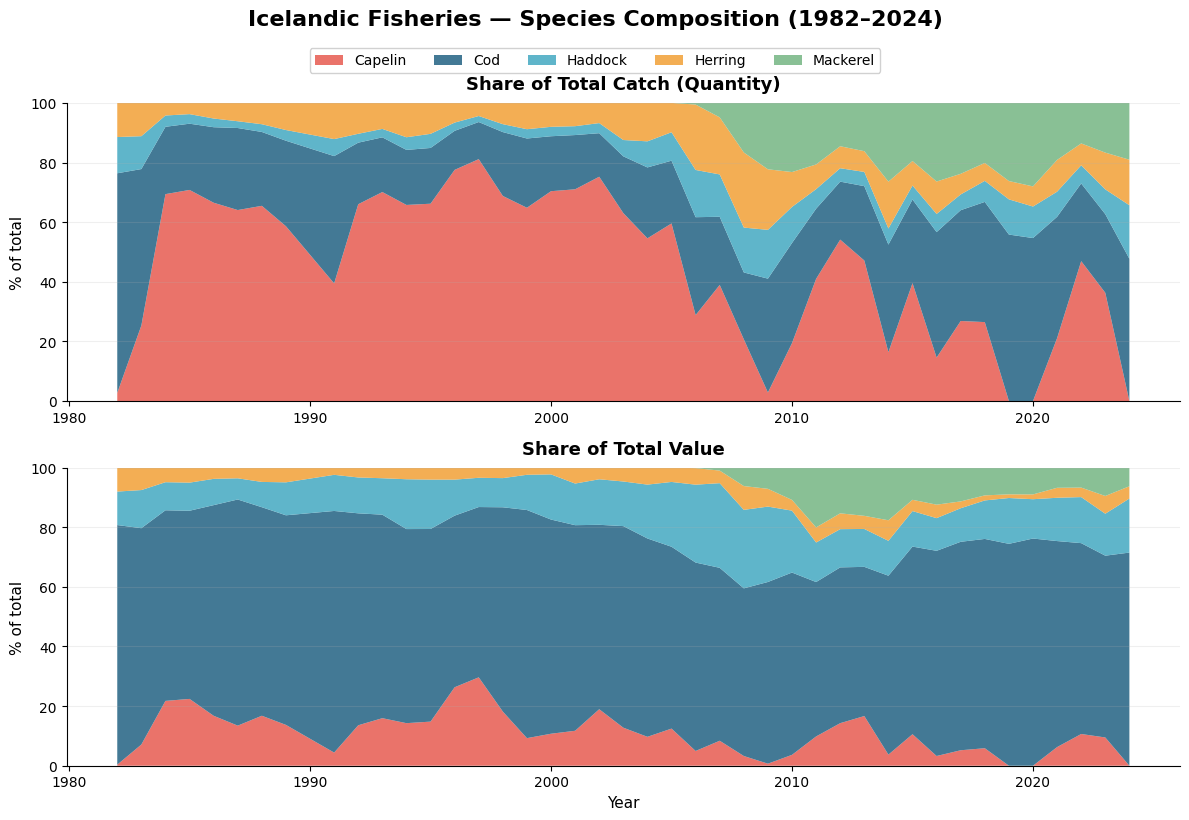

In [30]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("Icelandic Fisheries — Species Composition (1982–2024)", fontsize=16, fontweight="bold", y=1.02)

# Quantity share
qty_yearly = combined_df.groupby(["Year", "Species"], as_index=False)["Quantity"].sum()
pivot_qty = qty_yearly.pivot(index="Year", columns="Species", values="Quantity").fillna(0)
pivot_qty_pct = pivot_qty.div(pivot_qty.sum(axis=1), axis=0) * 100
color_list = [colors[s] for s in pivot_qty.columns]

ax1.stackplot(
    pivot_qty_pct.index.values, pivot_qty_pct.values.T,
    labels=pivot_qty_pct.columns.tolist(), colors=color_list, alpha=0.9
)
ax1.set_title("Share of Total Catch (Quantity)", fontsize=13, fontweight="bold", pad=10)
ax1.set_ylabel("% of total", fontsize=11)
ax1.set_ylim(0, 100)

# Value share
val_yearly = combined_df.groupby(["Year", "Species"], as_index=False)["Value"].sum()
pivot_val = val_yearly.pivot(index="Year", columns="Species", values="Value").fillna(0)
pivot_val_pct = pivot_val.div(pivot_val.sum(axis=1), axis=0) * 100
color_list_v = [colors[s] for s in pivot_val.columns]

ax2.stackplot(
    pivot_val_pct.index.values, pivot_val_pct.values.T,
    labels=pivot_val_pct.columns.tolist(), colors=color_list_v, alpha=0.9
)
ax2.set_title("Share of Total Value", fontsize=13, fontweight="bold", pad=10)
ax2.set_ylabel("% of total", fontsize=11)
ax2.set_ylim(0, 100)
ax2.set_xlabel("Year", fontsize=11)

for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, 0.98), framealpha=0.9, edgecolor="#ccc")

plt.tight_layout()
plt.show()

Clearly monetary value varies between species as the composition share in terms of Quantity and Value is disproportionate. Now, taking a look at the landing ports we can see that the number of landing ports accounting for more than 5% of the total yearly catch is relatively stable.

<a id="fig5"></a>

**Figure 5: Ports Accounting for More Than 5% of Total Catch**

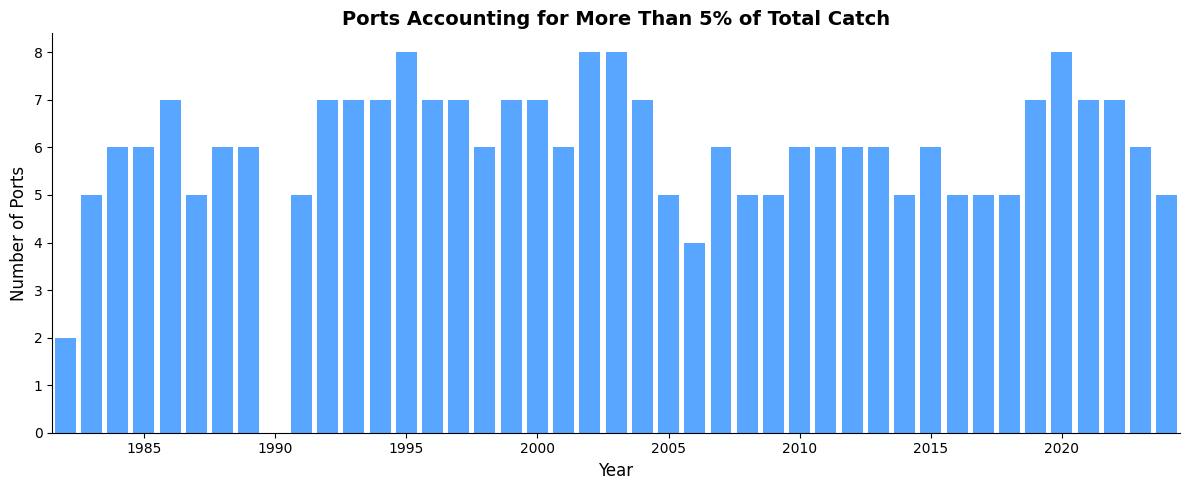

In [31]:
import matplotlib.pyplot as plt
import numpy as np

share = 0.05

# Total catch per port per year
port_year_qty = (
    combined_df.groupby(["Year", "Port"])["Quantity"]
    .sum()
    .reset_index()
)

# Total catch per year
year_totals = port_year_qty.groupby("Year")["Quantity"].sum().rename("YearTotal")

# Merge and compute each port's share
port_year_qty = port_year_qty.merge(year_totals, on="Year")
port_year_qty["Share"] = port_year_qty["Quantity"] / port_year_qty["YearTotal"]

# Count ports with >1% share each year
ports_above_1pct = (
    port_year_qty[port_year_qty["Share"] > share]
    .groupby("Year")
    .size()
    .reset_index(name="NumPorts")
)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(ports_above_1pct["Year"], ports_above_1pct["NumPorts"],
       color="#58a6ff", linewidth=0.5)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Ports", fontsize=12)
ax.set_title("Ports Accounting for More Than 5% of Total Catch", fontsize=14, fontweight="bold")

ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(ports_above_1pct["Year"].min() - 0.5, ports_above_1pct["Year"].max() + 0.5)

plt.tight_layout()
plt.show()

Finally, we examine catch quantity trends for the five largest landing ports. Significant variations appear between years, and three of the ports show reduced landing quantities after 2000 compared with earlier periods.

<a id="fig6"></a>

**Figure 6: Top Port Catch Trends**

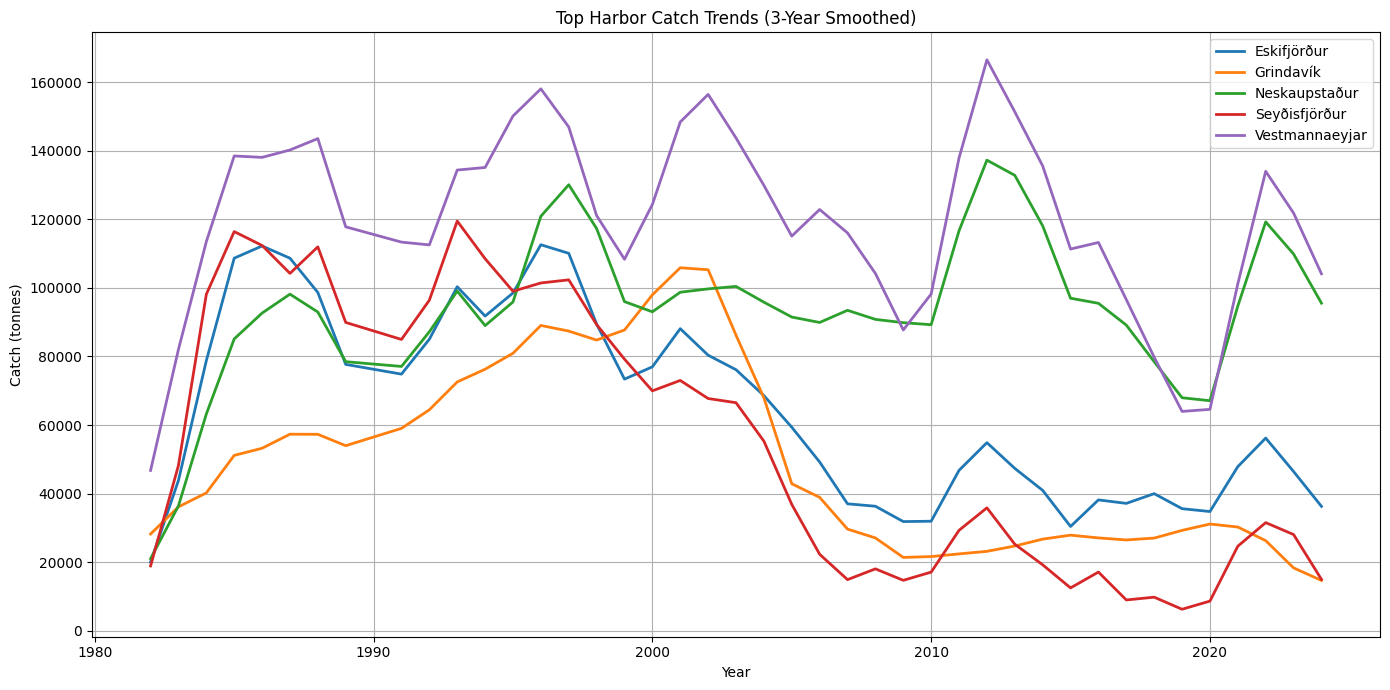

In [32]:
top5 = (
    combined_df
    .groupby("Port")["Quantity"]
    .sum()
    .nlargest(5)
    .index
)

harbor_trends = (
    combined_df[combined_df["Port"].isin(top5)]
    .groupby(["Year", "Port"])["Quantity"]
    .sum()
    .unstack()
)

# 3-year rolling average
harbor_smoothed = harbor_trends.rolling(window=3, center=True, min_periods=1).mean()

plt.figure(figsize=(14, 7))

for col in harbor_smoothed.columns:
    plt.plot(
        harbor_smoothed.index,
        harbor_smoothed[col],
        linewidth=2,
        label=col
    )

plt.title("Top Harbor Catch Trends (3-Year Smoothed)")
plt.xlabel("Year")
plt.ylabel("Catch (tonnes)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Financial Data


The operating accounts dataset includes multiple financial metrics. To focus on the big picture of the industry's economic performance, we aggregate and filter these down to four key measures: Operating Revenue, Operating Expenses, Net Profit, and EBITDA. Note that this data is aggregated across all fisheries in the industry, so variations between individual companies are not obtainable. Also, the data dates back to 1997, not 1982 as for the catch data.

The key insight lies in the long-term trends of these metrics, which we explore in the following figure. 

<a id="fig_rev"></a>

**Figure 7: Icelandic Fisheries - Financial Overview**

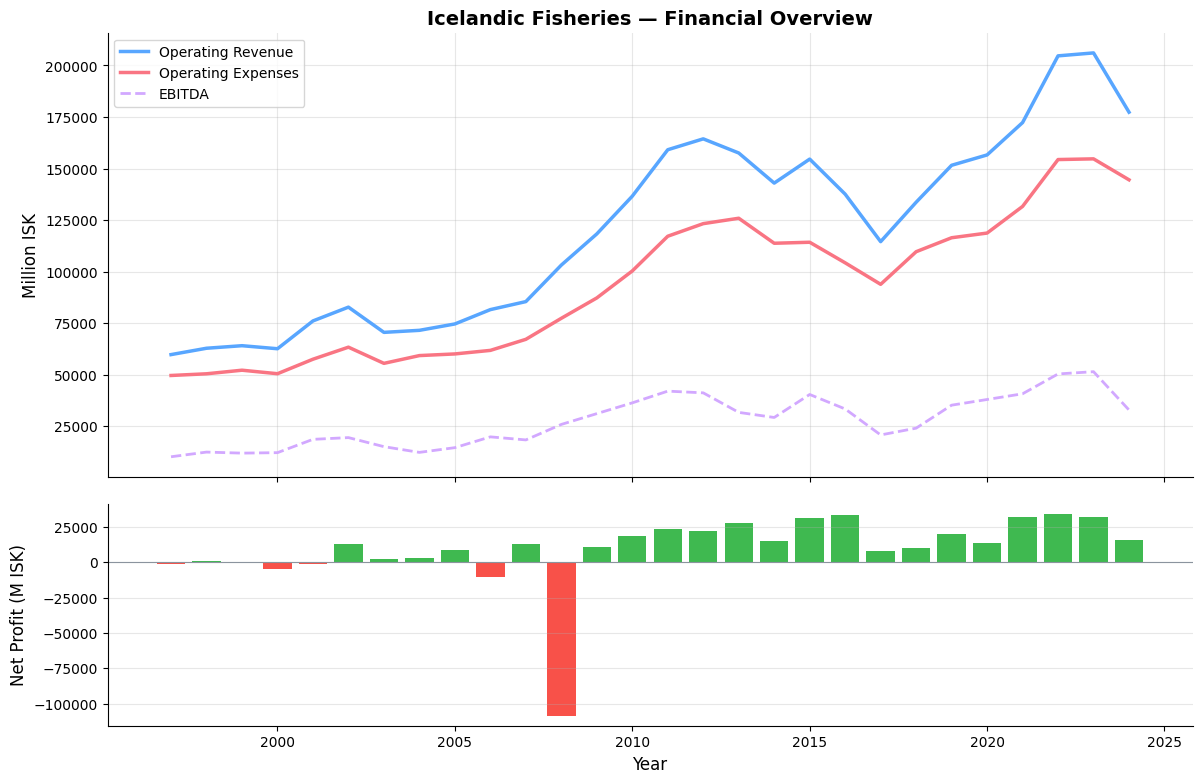

In [33]:
# load and clean data
df_finance_raw = pd.read_csv("rekstur_data.csv")
metric_map = {
    "1. Tekjur alls": "Operating Revenue",
    "2  Gjöld alls": "Operating Expenses",
    "Hreinn hagnaður (EBT)": "Net Profit",
    "Verg hlutdeild fjármagns (EBITDA)": "EBITDA",
}

# Filter to selected metrics and "Samtals" (total across all ship types)
df_finance = df_finance_raw[
    (df_finance_raw["Tekju- og gjaldaliðir"].isin(metric_map.keys()))
    & (df_finance_raw["Tegund skipa"] == "Samtals")
].copy()

# Translate and rename
df_finance["Metric"] = df_finance["Tekju- og gjaldaliðir"].map(metric_map)
df_finance.rename(columns={
    "Ár": "Year",
    "Rekstraryfirlit fiskveiða 1997-2024": "Amount"
}, inplace=True)

# Convert to numeric
df_finance["Amount"] = pd.to_numeric(df_finance["Amount"], errors="coerce")

# Pivot to one row per year
df_finance = (
    df_finance
    .pivot_table(index="Year", columns="Metric", values="Amount", aggfunc="first")
    .reset_index()
)
df_finance.columns.name = None

# plot

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[2, 1],
                                sharex=True, gridspec_kw={"hspace": 0.08})

# ── Top: Revenue, Expenses, EBITDA ──
ax1.plot(df_finance["Year"], df_finance["Operating Revenue"], linewidth=2.5,
         label="Operating Revenue", color="#58a6ff")
ax1.plot(df_finance["Year"], df_finance["Operating Expenses"], linewidth=2.5,
         label="Operating Expenses", color="#f97583")
ax1.plot(df_finance["Year"], df_finance["EBITDA"], linewidth=2,
         label="EBITDA", color="#d2a8ff", linestyle="--")

ax1.set_ylabel("Million ISK", fontsize=12)
ax1.set_title("Icelandic Fisheries — Financial Overview", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.spines[["top", "right"]].set_visible(False)

# ── Bottom: Net Profit bars (green/red) ──
colors = ["#3fb950" if v >= 0 else "#f85149" for v in df_finance["Net Profit"]]
ax2.bar(df_finance["Year"], df_finance["Net Profit"], color=colors, edgecolor="none", width=0.8)
ax2.axhline(0, color="#8b949e", linewidth=0.8)

ax2.set_xlabel("Year", fontsize=12)
ax2.set_ylabel("Net Profit (M ISK)", fontsize=12)
ax2.grid(True, alpha=0.3, axis="y")
ax2.spines[["top", "right"]].set_visible(False)

fig.subplots_adjust(hspace=0.08)
plt.show()

This data suggests that the fishing industry has had strong economic performance in recent years compared with the pre-2005 period, with net profit growing considerably since then. Note that 2008 stands out as a stark outlier, corresponding to the financial crisis that hit Iceland particularly hard.

### Catch Quota Data

Finally, we turn to the catch quota dataset. The Icelandic catch quota system was established in 1984, permitting fishing companies to harvest quantities corresponding to their annual share of the total allowable catch for each season. In 1990, free trade of these quotas was allowed, and this dataset therefore dates back to that year.

This data is of particular interest for our story as it neatly illustrates the concentration within the fishing industry. Before exploring it, we perform some cleaning and preprocessing, involving translation and filtering by our species list, mapping to the effective year of implementation, and determination of inter-company trading, as many quota movements occur within the same company

In [34]:
df_quota_raw = pd.read_csv("Hlutdeildir.csv")

# Clean up
df_quota = df_quota_raw.drop(columns=["Unnamed: 0"]).copy()

species = ['Cod', 'Haddock', 'Herring', 'Capelin', 'Mackerel']

# Translate columns
df_quota.rename(columns={
    "Fiskveiðiár": "Fishing Year",
    "Skr.nr.": "Reg. No.",
    "Heiti": "Vessel Name",
    "Útgerðarflokkur": "Fleet Category",
    "Kvótategund": "Quota Species",
    "Hlutdeildir úr gildi": "Quota Expiry",
    "Hlutdeild í upphafi": "Share Start",
    "Hlutdeild í lok": "Share End",
    "Hlutdeildarbreyting": "Share Change",
    "Útgerð": "Operator"
}, inplace=True)

# Extract the effective year (later year from "2020/2021" -> 2021)
df_quota["Year"] = df_quota["Fishing Year"].str.split("/").str[1].astype(int)

species_keep = {
    "Þorskur": "Cod",
    "Ýsa": "Haddock",
    "Síld": "Herring",
    "Loðna": "Capelin",
    "Makríll": "Mackerel",
}

df_quota["Species"] = df_quota["Quota Species"].map(species_keep)
df_quota = df_quota.dropna(subset=["Species"])

df_quota["Direction"] = df_quota["Share Change"].apply(
    lambda x: "Gain" if x > 0 else ("Loss" if x < 0 else "No Change")
)

df_quota["Abs Change"] = df_quota["Share Change"].abs()


# Focus on rows with actual changes
changes = df_quota[df_quota["Share Change"] != 0].copy()

# For each (Year, Species), try to match losses to gains of similar magnitude
def flag_inter_operator(group):
    losses = group[group["Direction"] == "Loss"].copy()
    gains = group[group["Direction"] == "Gain"].copy()
    
    matched = set()
    
    for li, lrow in losses.iterrows():
        for gi, grow in gains.iterrows():
            if gi in matched:
                continue
            # Match if the absolute values are close (within 1% tolerance)
            if lrow["Operator"] != grow["Operator"] and \
               abs(lrow["Abs Change"] - grow["Abs Change"]) / max(lrow["Abs Change"], 1e-12) < 0.01:
                matched.add(li)
                matched.add(gi)
                break
    
    group["Inter-Operator"] = group.index.isin(matched)
    return group

df_quota["Inter-Operator"] = False
changes = changes.groupby(["Year", "Species"], group_keys=False).apply(flag_inter_operator, include_groups=False)
df_quota.loc[changes.index, "Inter-Operator"] = changes["Inter-Operator"]

has_change = df_quota[df_quota["Share Change"] != 0]

print(f"Total transfers: {has_change.shape[0]}")
print(f"Inter-company transfers: {df_quota['Inter-Operator'].sum()}")
print(f"Internal/other changes:   {((df_quota['Share Change'] != 0) & ~df_quota['Inter-Operator']).sum()}")

Total transfers: 18559
Inter-company transfers: 8098
Internal/other changes:   10461


The 10 largest catch quota trades are as follows. Note the share change corresponds to percentage share of the total annual allowed catch. 

In [35]:
df_quota[(df_quota["Inter-Operator"]) & (df_quota["Direction"] == "Gain")].nlargest(10, "Abs Change")[
    ["Year", "Species", "Operator", "Share Change", "Direction"]
]

,Year,Species,Operator,Share Change,Direction
63306,2007,Herring,Samherji hf.,8.870579,Gain
81596,2022,Capelin,Útgerðarfélag Reykjavíkur hf.,5.840000,Gain
76422,2001,Herring,Þingey ehf.,5.662441,Gain
9698,2016,Herring,Brim hf.,5.545482,Gain
67832,2022,Herring,Síldarvinnslan hf.,5.545387,Gain
23444,2004,Herring,Gjögur hf.,3.577336,Gain
48590,2007,Herring,Langanes hf,3.444148,Gain
67644,2008,Herring,Síldarvinnslan hf.,3.345482,Gain
69263,2005,Herring,Skinney-Þinganes hf.,3.327389,Gain
76432,2004,Herring,Þingey ehf.,3.327289,Gain


So, large transfers have occurred, and the top 10 have all happened after 2000. Lets now look at the quota concentration by looking at the share evolution for the largest fishing companies, first per species, and then aggregated accross our five species. Note that we omit mackerel here, as the data only dates back to 2019. Also note the y-axis ranges vary between sub-figures.

<a id="fig8"></a>

**Figure 8: Quota Concentration — Top 5 Fishing Companies per Species**

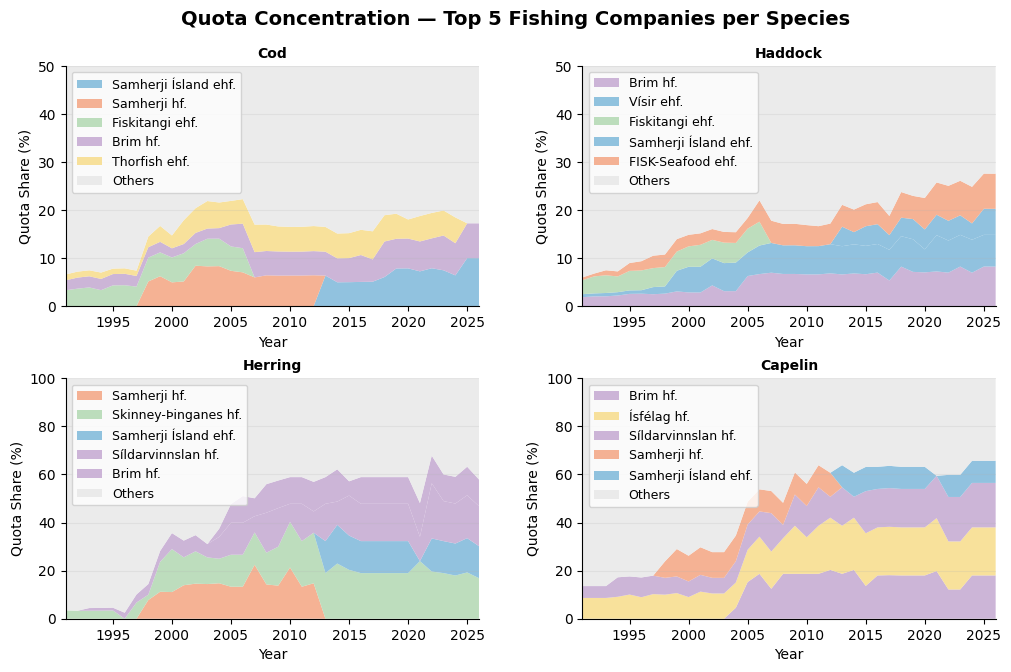

In [36]:
species_list = ["Cod", "Haddock", "Herring", "Capelin"]

soft_colors = ["#7eb8da", "#f4a582", "#b2d8b2", "#c4a8d1", "#f7dc8a"]
others_color = "#e8e8e8"

# Build a global color map: collect all top5 operators across all species
all_top_ops = []
for species in species_list:
    sp = df_quota[df_quota["Species"] == species]
    op_year = sp.groupby(["Year", "Operator"])["Share End"].sum().reset_index()
    top5 = op_year.groupby("Operator")["Share End"].mean().nlargest(5).index.tolist()
    for op in top5:
        if op not in all_top_ops:
            all_top_ops.append(op)

# Extend palette if needed
extended_palette = (soft_colors * ((len(all_top_ops) // len(soft_colors)) + 1))[:len(all_top_ops)]
operator_color_map = {op: extended_palette[i] for i, op in enumerate(all_top_ops)}
operator_color_map["Others"] = others_color

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, species in zip(axes, species_list):
    sp = df_quota[df_quota["Species"] == species]
    
    op_year = sp.groupby(["Year", "Operator"])["Share End"].sum().reset_index()
    
    top5_ops = (
        op_year.groupby("Operator")["Share End"]
        .mean()
        .nlargest(5)
        .index.tolist()
    )
    
    op_year["Group"] = op_year["Operator"].where(op_year["Operator"].isin(top5_ops), "Others")
    grouped = op_year.groupby(["Year", "Group"])["Share End"].sum().reset_index()
    pivot = grouped.pivot(index="Year", columns="Group", values="Share End").fillna(0)
    
    col_order = [c for c in top5_ops if c in pivot.columns] + (["Others"] if "Others" in pivot.columns else [])
    pivot = pivot[col_order]
    
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    
    plot_colors = [operator_color_map[c] for c in pivot_pct.columns]
    
    ax.stackplot(
        pivot_pct.index.values, pivot_pct.values.T,
        labels=pivot_pct.columns.tolist(), colors=plot_colors, alpha=0.85
    )
    
    ax.set_title(species, fontsize=10, fontweight="bold")
    ax.set_ylabel("Quota Share (%)")
    ax.set_xlim(df_quota["Year"].min(), df_quota["Year"].max())
    ax.legend(fontsize=9, loc="upper left", ncol=1)
    ax.grid(True, alpha=0.2, axis="y")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Year")
    
    if species in ["Cod", "Haddock"]:
        ax.set_ylim(0, 50)
    else:
        ax.set_ylim(0, 100)

fig.suptitle("Quota Concentration — Top 5 Fishing Companies per Species", fontsize=14, fontweight="bold")
fig.subplots_adjust(hspace=0.3, wspace=0.25, top=0.90)
plt.show()

<a id="fig9"></a>

**Figure 9: Quota Concentration — Top 10 Fishing Companies Across All Species**

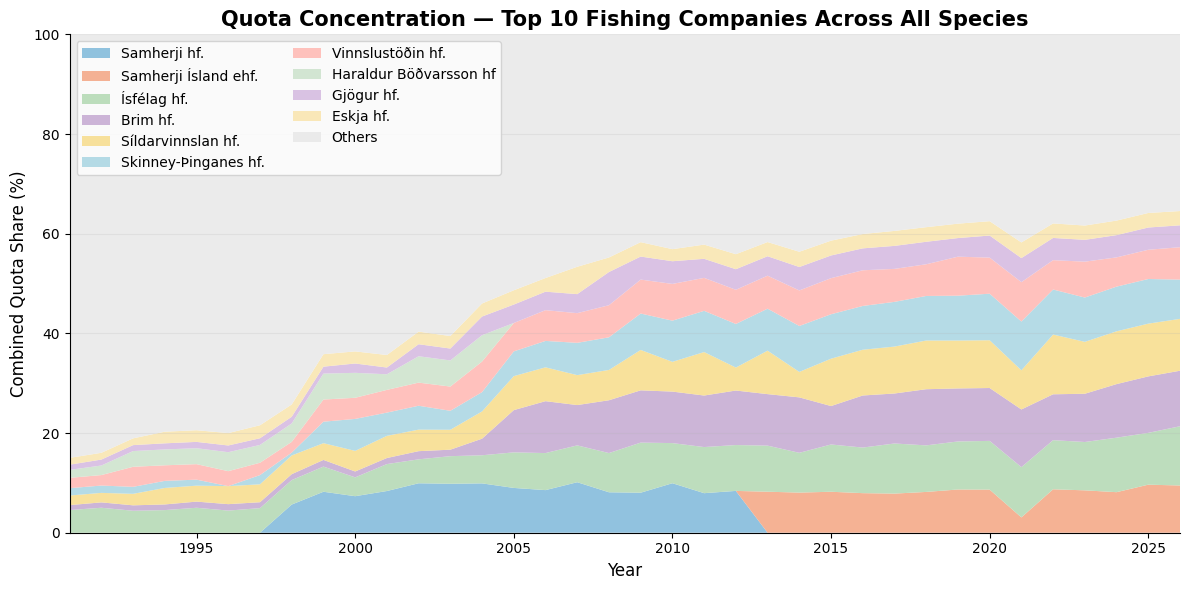

In [37]:
# Aggregate share across all species per operator per year
op_year_all = (
    df_quota[df_quota["Species"].isin(["Cod", "Haddock", "Herring", "Capelin"])]
    .groupby(["Year", "Operator"])["Share End"]
    .sum()
    .reset_index()
)

top10_ops = (
    op_year_all.groupby("Operator")["Share End"]
    .mean()
    .nlargest(10)
    .index.tolist()
)

op_year_all["Group"] = op_year_all["Operator"].where(op_year_all["Operator"].isin(top10_ops), "Others")
grouped = op_year_all.groupby(["Year", "Group"])["Share End"].sum().reset_index()
pivot = grouped.pivot(index="Year", columns="Group", values="Share End").fillna(0)

col_order = [c for c in top10_ops if c in pivot.columns] + (["Others"] if "Others" in pivot.columns else [])
pivot = pivot[col_order]

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

soft_colors = ["#7eb8da", "#f4a582", "#b2d8b2", "#c4a8d1", "#f7dc8a",
               "#a8d5e2", "#ffb7b2", "#cce2cb", "#d4b8e0", "#f9e4ad"]
others_color = "#e8e8e8"

plot_colors = [soft_colors[i] for i, c in enumerate(pivot_pct.columns) if c != "Others"]
if "Others" in pivot_pct.columns:
    plot_colors.append(others_color)

fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(
    pivot_pct.index.values, pivot_pct.values.T,
    labels=pivot_pct.columns.tolist(), colors=plot_colors, alpha=0.85
)

ax.set_title("Quota Concentration — Top 10 Fishing Companies Across All Species", fontsize=15, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Combined Quota Share (%)", fontsize=12)
ax.set_xlim(df_quota["Year"].min(), df_quota["Year"].max())
ax.set_ylim(0, 100)
ax.legend(fontsize=10, loc="upper left", ncol=2)
ax.grid(True, alpha=0.2, axis="y")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

These figures clearly suggest a concentration of quotas, occurring primarily between 1997 and 2010, which is a valuable insight for our data story.

# 3. Data Analysis

Central to the data analysis was identifying the main perspectives to be presented in the data story visualization. These include quota and landing port concentration, revenue trends, and the long-term stability of the industry.

Our exploratory data analysis, presented in the previous chapter, focused on gaining a deeper understanding of the trends and dynamics within the data. For the catch data, exploring power-law dynamics in terms of species and landing ports was a priority. The exploration also examined variations in catch trends to assess catch and stock stability over time. For the financial data, the primary interest was the long term trajectory of industry’s economical performance. Finally, the catch quota data was explored with a focus on understanding the concentration dynamics present.

The main takeaways from the data analysis are the following:
- The catch data generally exhibits power-law dynamics. Both the individual catch instances, with the top 5% of entries accounting for approximately 72% of total value (as shown in figure [Figure 1](#fig1) and block []), and the species distribution, with five species accounting for 75% of total quantity (as shown in figure [Figure 2](#fig2)), display this tendency. This finding guided the decision to limit the visualisations to the five main fish species.
- Assessment of concentration within the industry is a key narrative to be explored in the data story. The landing port data does not indicate a strong concentration trend, as the number of ports accounting for more than 5% of total catch quantity remains relatively stable over the time period, as portrayed in figure [Figure 5](#fig5).
- A central concern in the data story is the stability offered by the catch quota system. The visualisation of catch data in [Figure 3](#fig3) does not reveal strong stability in catch sizes over time. Catch sizes vary considerably from the mean, and the same dynamic is shown in figure [Figure 4](#fig4).
- The economic dimension of the fishing industry's evolution is an important aspect for the data story. This is explored in [Figure 7](#fig_rev), which shows strong growth in operating revenue and EBITDA over the time period. A clear profit contrast is visible between the pre-2005 and post-2008 years.
- The catch quota data is likely illustrative of the concentration tendency often raised in discussions of the quota system. [Figure 8](#fig8) and [Figure 9](#fig9) support this narrative, with the strongest rise in concentration occurring between 1997 and 2010.

# 4. Genre

The project mainly uses an **Interactive Slideshow** narrative structure, combined with elements of a **Martini Glass** and **Drill-Down Story** structure. The visualization guides the user through Icelandic fisheries over time while still allowing free exploration of ports, species, and trends.

From the **Visual Narrative** categories described by Segel and Heer, the project uses:

- **Visual Structuring** through a consistent dark theme, chronological ordering, and repeated layouts across years.
- **Highlighting** through color emphasis, annotations, event markers, and focused comparisons.
- **Transition Guidance** through the year slider, slideshow controls, and animated progression over time.

From the **Narrative Structure** categories, the project uses:

- **Interactive Slideshow** as the main structure, presenting the fisheries year-by-year.
- **Martini Glass** by first guiding the viewer through important stories before allowing free exploration.
- **Drill-Down Story** by enabling users to move from national trends to specific ports or species for deeper analysis.

# 5. Visualizations

# 6. Discussion

### What went well?

The project successfully combined data visualization and storytelling to show long-term changes in Icelandic fisheries. The interactive map and slideshow came out like we had hoped, it was easy to explore trends across both time and geography. The page created looks good and is easy to navigate. Several interesting stories were revealed in the data, such as the decline of capelin, the rise of mackerel, and the downturn of Grindavík after volcanic activity. We feel that the plots made are easy to interpret and helped present the data from different perspectives

### What is still missing? What could be improved?

More interactivity could be added, such as filtering by species, port, or time period directly in the interface, this would allow users to explore the dataset in greater detail and create their own insights. The project currently focuses mostly on catch quantity and value, but does not include social or economic impacts on communities. We are both relatively familiar with Icelandic fisheries so there are probably some things missing for people unfamiliar with Icelandic fisheries, but additional annotations and explanations could make the narrative clearer for users.

# 7. Contributions

Egill Bjarni Gíslason: 

- Website: Made all the maps and the guided story that the user goes through when they open the website. 

- Notebook: Did most of parts 1, 2, 3 and 5.

Hlynur Blær Sigurðsson: 

- Website: Made the plots on the side of the maps along with the extra stories linked. 

- Notebook: Did parts 4 and 6 along with the data preprocessing part and some text in part 2.

We both read over each others text and code and jointly made the html for the website.

# 8. References

<a id="ref1"></a> Catch and value by species, place of landing and months 1982-2024: https://px.hagstofa.is/pxen/pxweb/en/Atvinnuvegir/Atvinnuvegir__sjavarutvegur__aflatolur__londunarhafnir/SJA09042.px/

<a id="ref2"></a> Operating accounts of fishing: https://px.hagstofa.is/pxen/pxweb/en/Atvinnuvegir/Atvinnuvegir__sjavarutvegur__afkomasja/SJA08101.px/

<a id="ref3"></a> Catch quota: https://island.is/v/gagnasidur-fiskistofu/gagnasidur?pageName=ReportSection4ce086cbd6149a60bd90&c0de6d7f183a590c4961=%7B%22filters%22%3A%5B%5D%2C%22targets%22%3A%5B%7B%22table%22%3A%22Fiskveidiar%22%2C%22column%22%3A%22Fiskvei%C3%B0i%C3%A1r%22%7D%5D%7D&85a21c61642ce088d373=%7B%22filters%22%3A%5B%5D%2C%22targets%22%3A%5B%7B%22table%22%3A%22Hlutdeildastada%22%2C%22column%22%3A%22Kv%C3%B3tategund%22%7D%5D%7D